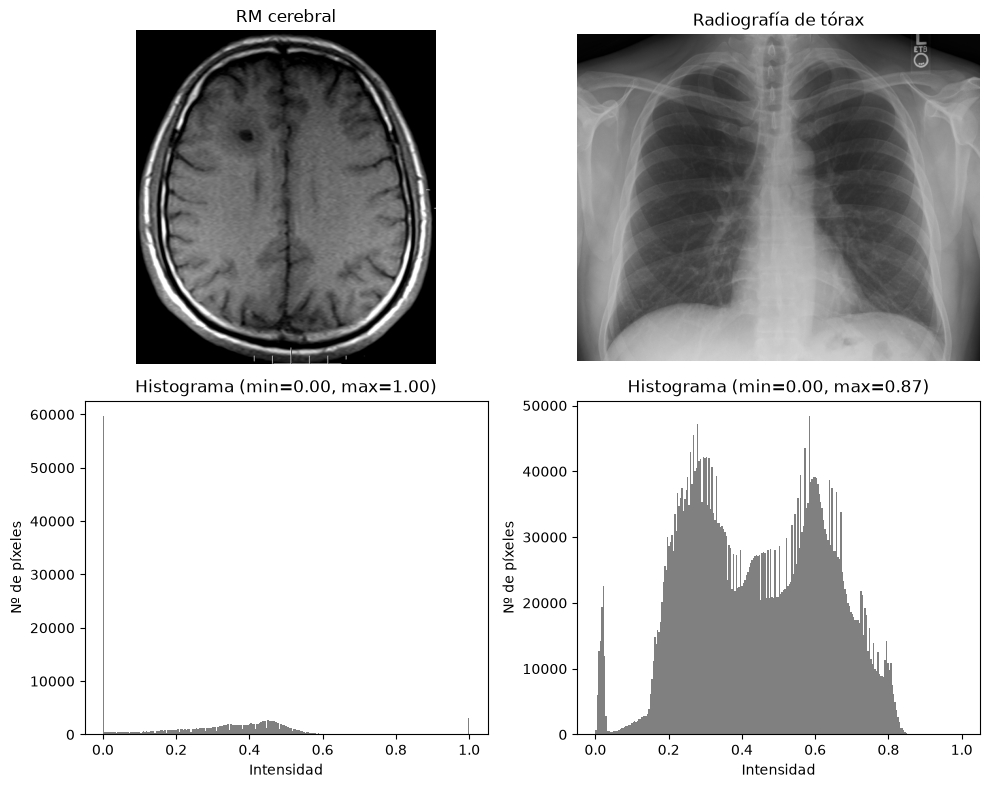

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io, img_as_float, color

def load_gray(path):
    img = io.imread(path)
    if img.ndim == 3:
        img = color.rgb2gray(img[..., :3])
    return img_as_float(img)

# Rutas relativas compatibles con ejecución desde /notebooks o desde la raíz del proyecto
DATA_DIR = Path("../data/raw") if Path("../data/raw").exists() else Path("data/raw")
img1 = load_gray(DATA_DIR / "Brain_MRI_131749_T1.png")
img2 = load_gray(DATA_DIR / "Chest_Xray_PA_3-8-2010.png")

images = [img1, img2]
titles = ["RM cerebral", "Radiografía de tórax"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, (im, t) in enumerate(zip(images, titles)):
    # Fila superior: imagen
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(t)
    axes[0, col].axis("off")

    # Fila inferior: histograma
    axes[1, col].hist(im.ravel(), bins=256, range=(0, 1), color="gray")
    axes[1, col].set_xlabel("Intensidad")
    axes[1, col].set_ylabel("Nº de píxeles")
    axes[1, col].set_title(f"Histograma (min={im.min():.2f}, max={im.max():.2f})")

plt.tight_layout()
plt.show()


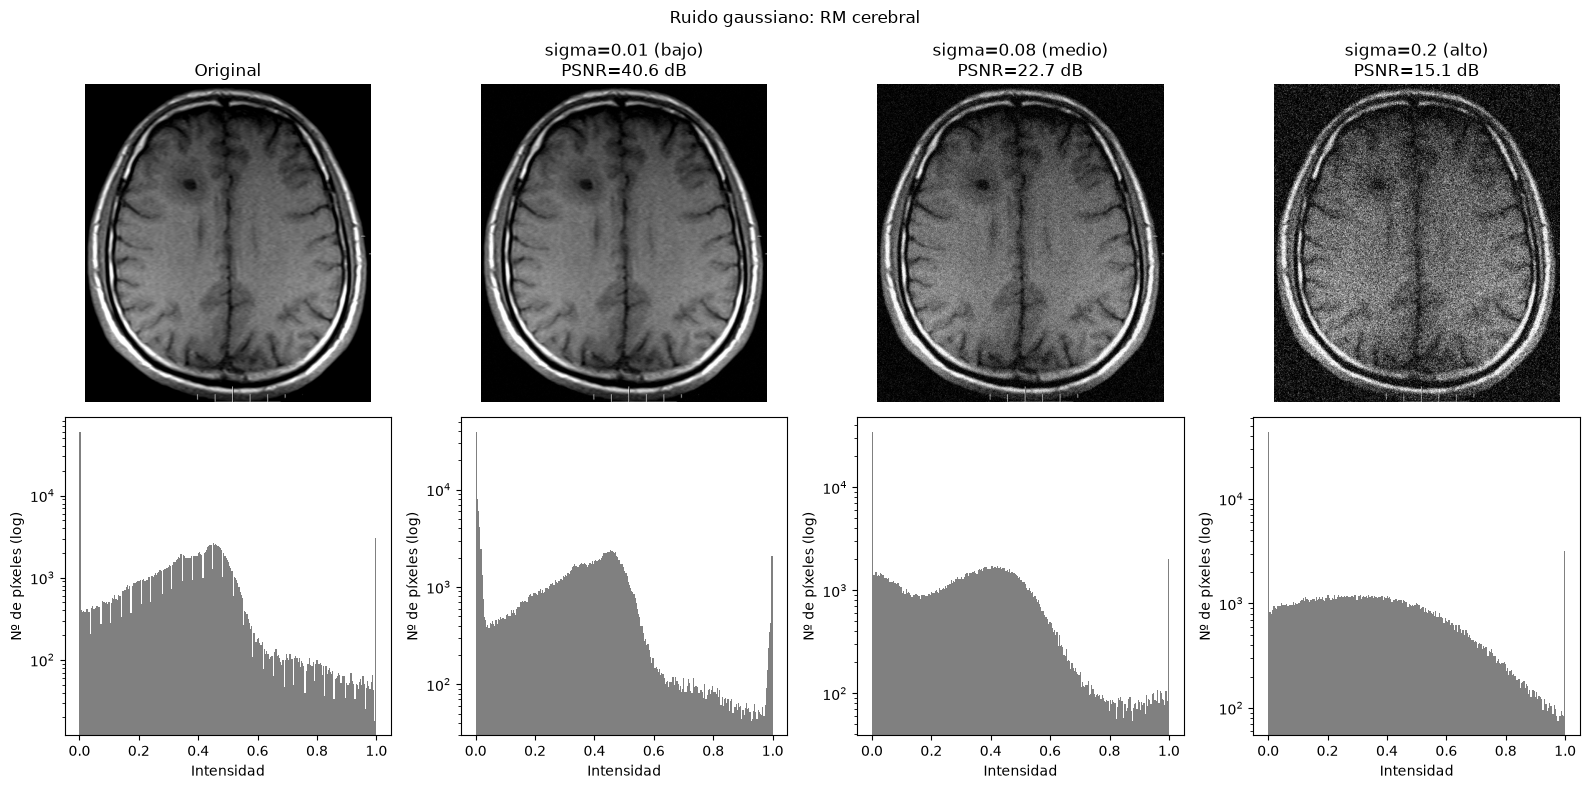

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io, img_as_float, color
from skimage.metrics import peak_signal_noise_ratio as psnr

def load_gray(path):
    img = io.imread(path)
    if img.ndim == 3:
        img = color.rgb2gray(img[..., :3])
    return img_as_float(img)

def add_gaussian_noise(img, sigma, rng):
    """Ruido gaussiano aditivo de media 0 y desviación típica sigma."""
    return np.clip(img + rng.normal(0.0, sigma, img.shape), 0.0, 1.0)

DATA_DIR = Path("../data/raw") if Path("../data/raw").exists() else Path("data/raw")
img1 = load_gray(DATA_DIR / "Brain_MRI_131749_T1.png")
img2 = load_gray(DATA_DIR / "Chest_Xray_PA_3-8-2010.png")

GAUSS_LEVELS = {"bajo": 0.01, "medio": 0.08, "alto": 0.20}

def show_gaussian(img, name, seed):
    rng = np.random.default_rng(seed)        # semilla fija: ruido reproducible
    versions = {"Original": img}
    for level, sigma in GAUSS_LEVELS.items():
        versions[f"sigma={sigma} ({level})"] = add_gaussian_noise(img, sigma, rng)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for col, (title, im) in enumerate(versions.items()):
        axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=1)
        p = "" if title == "Original" else f"\nPSNR={psnr(img, im, data_range=1.0):.1f} dB"
        axes[0, col].set_title(title + p)
        axes[0, col].axis("off")

        axes[1, col].hist(im.ravel(), bins=256, range=(0, 1), color="gray", log=True)
        axes[1, col].set_xlabel("Intensidad")
        axes[1, col].set_ylabel("Nº de píxeles (log)")
    fig.suptitle(f"Ruido gaussiano: {name}")
    plt.tight_layout()
    plt.show()

show_gaussian(img1, "RM cerebral", seed=100)
show_gaussian(img2, "Radiografía de tórax", seed=101)
